# Capstone Project — Student Version (Google Colab)
## Mixed Precision + Gradient Clipping with DistilBERT on `twitter.csv` (3‑Class Text Classification)

This notebook keeps the **same capstone ideas** (EDA → tokenization → dataset/dataloaders → AMP + gradient clipping training → evaluation → save/reload → inference → Gradio deployment), but it is rewritten to work with the **attached `twitter.csv` dataset**.

## What is this dataset?
Your `twitter.csv` file contains tweets labeled into **3 classes** (column `class`) and includes annotation counts (`hate_speech`, `offensive_language`, `neither`). We'll treat this as a **3‑class text classification** task.

### Class mapping used in this notebook
- **0 → Hate Speech**
- **1 → Offensive Language**
- **2 → Neither**

## Runtime type (important)
- Set Runtime type to: **T4 GPU**


# Task 0: Setup

### What you are learning
- How to set up a Colab environment for transformer fine-tuning.
- Why GPU matters for AMP (mixed precision) and fast training.


In [1]:
!pip install -q transformers pandas matplotlib seaborn scikit-learn tqdm


### Switch runtime to T4 GPU (required)
Runtime → Change runtime type → Hardware accelerator → **T4 GPU** → Save  
Runtime → Restart session  

After restarting, re-run from the top.


In [2]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


torch: 2.10.0+cu128
CUDA available: True
Using device: cuda


# Task 1: Load data + Exploratory Data Analysis (EDA)

### What you are learning
EDA helps you confirm:
- the dataset loaded correctly,
- labels look reasonable (0/1/2),
- whether the classes are imbalanced,
- how long tweets tend to be (helps choose `max_length`),
- how annotation vote columns relate to the final label.


## Step 1: Load `twitter.csv`

### What you are learning
- How to load and standardize columns.
- How to ensure `tweet` and `class` exist, even if the CSV has extra columns.


In [3]:
# In Colab, upload twitter.csv if it's not already present
if not os.path.exists("twitter.csv"):
    from google.colab import files
    uploaded = files.upload()
    print("Uploaded:", list(uploaded.keys()))

df = pd.read_csv("twitter.csv")

# Normalize column names for safety
df.columns = [c.strip().lower() for c in df.columns]

# Common versions of this dataset include an index-like column such as 'unnamed: 0'
df = df.drop(columns=[c for c in df.columns if c.startswith("unnamed")], errors="ignore")

# Validate required columns
required = {"tweet", "class"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {df.columns.tolist()}")

# Keep relevant columns (keep vote columns if present)
vote_cols = [c for c in ["hate_speech", "offensive_language", "neither", "count"] if c in df.columns]
df = df[["tweet", "class"] + vote_cols].copy()

# Ensure class is integer 0/1/2
df["class"] = df["class"].astype(int)

# Drop null tweets
df = df.dropna(subset=["tweet"]).reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()


Saving twitter.csv to twitter.csv
Uploaded: ['twitter.csv']
Rows: 24783
Columns: ['tweet', 'class', 'hate_speech', 'offensive_language', 'neither', 'count']


,tweet,class,hate_speech,offensive_language,neither,count
0,!!! RT @mayasolovely: As a woman you shouldn't...,2,0,0,3,3
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1,0,3,0,3
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1,0,3,0,3
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1,0,2,1,3
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1,0,6,0,6


## Step 2: Define label names

### What you are learning
Models use numeric labels, but humans read names.


In [4]:
label_names = {0: "Hate Speech", 1: "Offensive Language", 2: "Neither"}
df["label_name"] = df["class"].map(label_names)
df["label_name"].value_counts()


,count
label_name,
Offensive Language,19190
Neither,4163
Hate Speech,1430


## Step 3: EDA plots
You will plot:
1) Class distribution  
2) Tweet word-length histogram  
3) Tweet word-length boxplot by class  
4) Heatmap showing **average vote counts** per class (if vote columns exist)


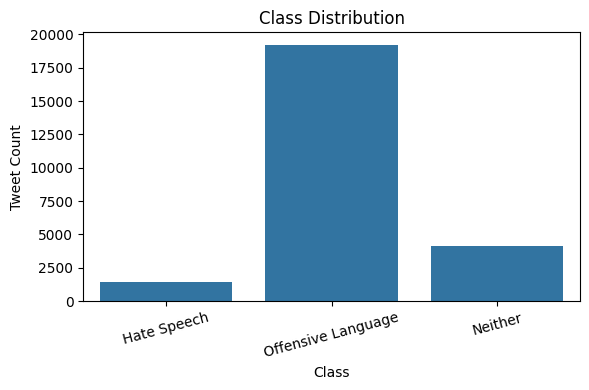

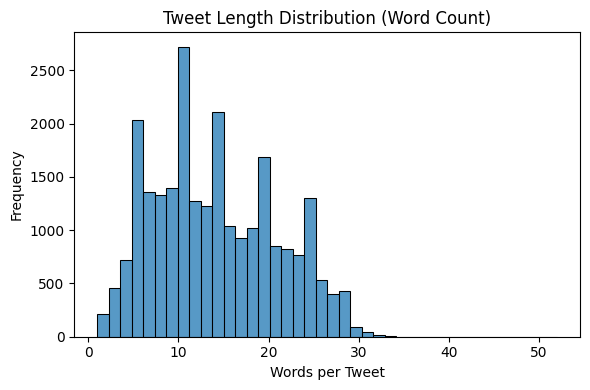

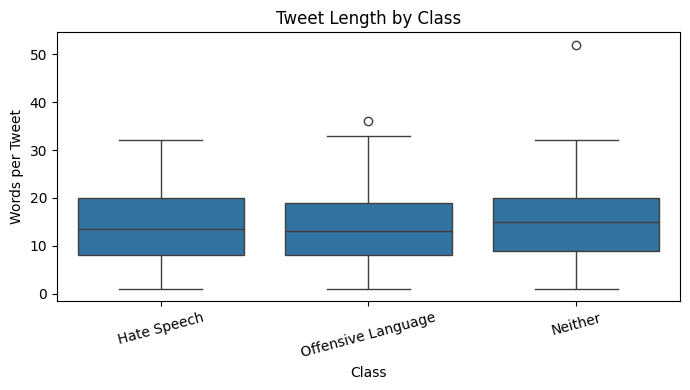

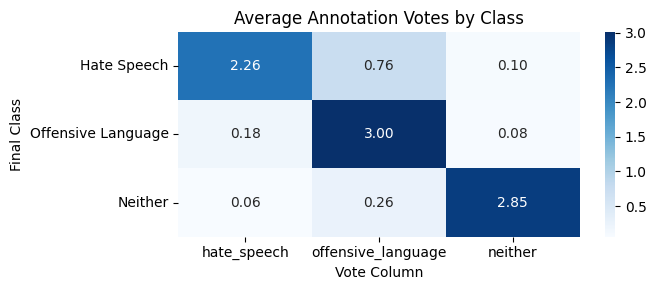

In [6]:
# 1) Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=df)
plt.title("Class Distribution")
plt.xticks([0,1,2], [label_names[i] for i in [0,1,2]], rotation=15)
plt.xlabel("Class")
plt.ylabel("Tweet Count")
plt.tight_layout()
plt.show()

# 2) Tweet length distribution (word count)
df["tweet_length_words"] = df["tweet"].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(6,4))
sns.histplot(df["tweet_length_words"], bins=40)
plt.title("Tweet Length Distribution (Word Count)")
plt.xlabel("Words per Tweet")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3) Tweet length by class
plt.figure(figsize=(7,4))
sns.boxplot(x="class", y="tweet_length_words", data=df)
plt.title("Tweet Length by Class")
plt.xticks([0,1,2], [label_names[i] for i in [0,1,2]], rotation=15)
plt.xlabel("Class")
plt.ylabel("Words per Tweet")
plt.tight_layout()
plt.show()

# 4) Heatmap: average vote counts by class (only if vote columns exist)
vote_cols_present = [c for c in ["hate_speech","offensive_language","neither"] if c in df.columns]
if vote_cols_present:
    agg = df.groupby("class")[vote_cols_present].mean().rename(index=label_names)
    plt.figure(figsize=(7,3))
    sns.heatmap(agg, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Average Annotation Votes by Class")
    plt.xlabel("Vote Column")
    plt.ylabel("Final Class")
    plt.tight_layout()
    plt.show()
else:
    print("Vote columns not found (hate_speech/offensive_language/neither). Skipping heatmap.")


## Mini challenge (Task 1)
Add a column for **character length** and plot a histogram.

### What you are learning
Character length can matter for social media text and helps you reason about truncation.


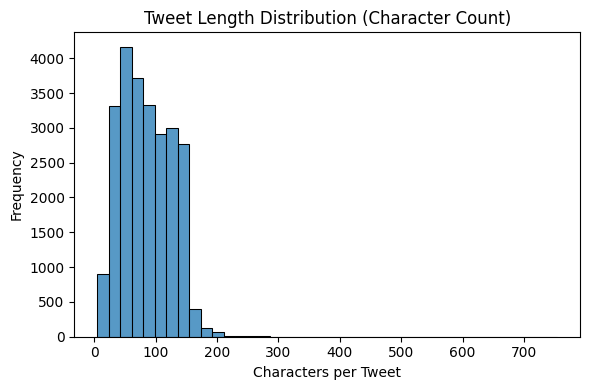

,tweet,tweet_length_words,tweet_length_chars,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,25,140,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,16,85,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,21,120,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,9,62,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,26,137,1


In [7]:
df["tweet_length_chars"] = df["tweet"].astype(str).apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df["tweet_length_chars"], bins=40)
plt.title("Tweet Length Distribution (Character Count)")
plt.xlabel("Characters per Tweet")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df[["tweet","tweet_length_words","tweet_length_chars","class"]].head()


# Task 2: Tokenization + Dataset + DataLoaders

### What you are learning
- How to tokenize tweets into DistilBERT inputs (`input_ids`, `attention_mask`).
- How to do a **stratified** train/validation split so class proportions stay similar.
- How to build a Dataset that returns model-ready tensors.


## Step 1: Create train/validation split (stratified)


In [8]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["tweet"],
    df["class"],
    test_size=0.2,
    stratify=df["class"],
    random_state=42
)

print("Train size:", len(train_texts))
print("Val size:  ", len(val_texts))
print("Train class dist:", train_labels.value_counts(normalize=True).sort_index().to_dict())
print("Val class dist:  ", val_labels.value_counts(normalize=True).sort_index().to_dict())


Train size: 19826
Val size:   4957
Train class dist: {0: 0.05770200746494502, 1: 0.7743367295470595, 2: 0.16796126298799557}
Val class dist:   {0: 0.05769618721000605, 1: 0.7742586241678434, 2: 0.16804518862215048}


## Step 2: Tokenizer + Dataset class


In [9]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class TwitterDataset(Dataset):
    def __init__(self, texts, labels, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding=True,
            max_length=max_length
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

MAX_LENGTH = 128
train_dataset = TwitterDataset(train_texts, train_labels, max_length=MAX_LENGTH)
val_dataset   = TwitterDataset(val_texts,   val_labels,   max_length=MAX_LENGTH)

print("Train dataset:", len(train_dataset))
print("Val dataset:  ", len(val_dataset))
print("Example keys:", train_dataset[0].keys())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train dataset: 19826
Val dataset:   4957
Example keys: dict_keys(['input_ids', 'attention_mask', 'labels'])


## Mini challenge (Task 2)
Try different `max_length` values and compare token counts.

### What you are learning
- Larger max_length → more compute/memory.
- Smaller max_length → more truncation.


In [ ]:
sample_texts = df["tweet"].sample(n=8, random_state=42).tolist()
for ml in [64, 128, 256]:
    # Corrected: Call the tokenizer directly instead of using batch_encode_plus
    enc = tokenizer(sample_texts, truncation=True, padding=False, max_length=ml)
    lens = [len(ids) for ids in enc["input_ids"]]
    print(f"max_length={ml} -> token counts:", lens)

max_length=64 -> token counts: [14, 24, 45, 35, 29, 30, 39, 21]
max_length=128 -> token counts: [14, 24, 45, 35, 29, 30, 39, 21]
max_length=256 -> token counts: [14, 24, 45, 35, 29, 30, 39, 21]


## Step 3: DataLoaders


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))


Train batches: 2479
Val batches:   620


# Task 3: Train DistilBERT with AMP + Gradient Clipping

### What you are learning
- How to fine-tune a pretrained transformer for **3-class classification** (`num_labels=3`).
- How AMP (`autocast` + `GradScaler`) improves speed and reduces GPU memory usage.
- How gradient clipping (`clip_grad_norm_`) stabilizes training.


## Step 1: Initialize model + optimizer


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    problem_type="single_label_classification"
).to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)

# AMP scaler (CUDA-only in this capstone)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

print("Model ready. num_labels =", model.num_labels)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready. num_labels = 3


/tmp/ipykernel_1739/3287159277.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


## Step 2: Training loop (1 epoch by default)


In [ ]:
EPOCHS = 1
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Training epoch {epoch+1}/{EPOCHS}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(**batch)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")


Training epoch 1/1:   0%|          | 0/2479 [00:00<?, ?it/s]/tmp/ipykernel_1739/631592032.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Training epoch 1/1: 100%|██████████| 2479/2479 [02:19<00:00, 17.82it/s]

Epoch 1 Avg Loss: 0.3285


## Mini challenge (Task 3)
Train for **3 epochs** and plot training loss.

### What you are learning
Loss curves help you see if training is converging.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_1739/2490448212.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Epoch 1 Avg Loss: 0.3166


3-epoch run 2/3: 100%|██████████| 2479/2479 [02:15<00:00, 18.23it/s]


Epoch 2 Avg Loss: 0.2638


3-epoch run 3/3: 100%|██████████| 2479/2479 [02:15<00:00, 18.30it/s]


Epoch 3 Avg Loss: 0.2278


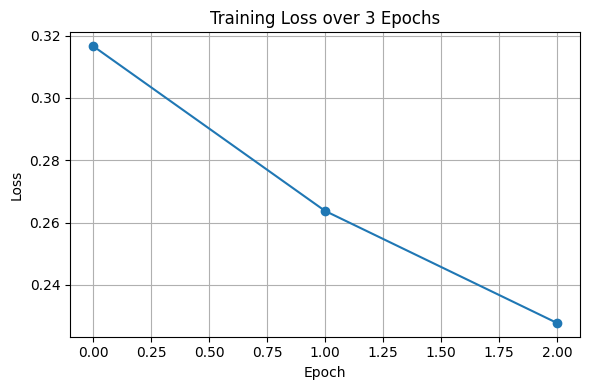

In [ ]:
# Reinitialize the model for a clean 3-epoch run
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    problem_type="single_label_classification"
).to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

losses_3 = []
for epoch in range(3):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"3-epoch run {epoch+1}/3"):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(**batch)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses_3.append(avg_loss)
    print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")

plt.figure(figsize=(6,4))
plt.plot(losses_3, marker="o")
plt.title("Training Loss over 3 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


# Task 4: Evaluate + Save/Reload + Inference

### What you are learning
- How to evaluate with a **classification report** (precision/recall/F1 per class).
- How to save and reload a fine-tuned transformer + tokenizer.
- How to run inference on new tweets.


## Step 1: Evaluation on validation set


In [ ]:
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    print("Classification Report:\n")
    print(classification_report(
        all_labels, all_preds,
        target_names=[label_names[i] for i in [0,1,2]]
    ))
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = evaluate_model(model, val_loader)


## Mini challenge (Task 4)
Add a confusion matrix visualization.

### What you are learning
A confusion matrix shows which classes your model mixes up most often.


In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names[i] for i in [0,1,2]])
disp.plot(cmap="Blues", xticks_rotation=20)
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()


## Step 2: Save the model and tokenizer


In [ ]:
SAVE_DIR = "./tweet_classifier_model"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Saved model + tokenizer to {SAVE_DIR}")


## Step 3: Reload and create an inference function


In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(SAVE_DIR)
model = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
model.eval()

def predict_class(tweet: str) -> str:
    inputs = tokenizer(tweet, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    pred = torch.argmax(logits, dim=1).item()
    return label_names.get(pred, str(pred))

# Try a few examples
print(predict_class("I hate you and everything you stand for."))
print(predict_class("You are so stupid."))
print(predict_class("Have a nice day everyone!"))


# Task 5: Deploy as a Gradio app

### What you are learning
- How to wrap inference into a simple web UI.
- How to launch a shareable demo link using `share=True`.


In [ ]:
!pip install -q gradio


In [ ]:
import gradio as gr

def gradio_predict(tweet):
    return predict_class(tweet)

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=3, label="Enter a tweet"),
    outputs=gr.Textbox(label="Predicted Class"),
    title="Tweet Classifier (DistilBERT + AMP + Gradient Clipping)",
    description="Classifies tweets into Hate Speech / Offensive Language / Neither.",
    examples=[
        ["I can't stand these people, they're disgusting."],
        ["You're an idiot."],
        ["Thanks for the help, I really appreciate it!"]
    ]
)

demo


In [ ]:
demo.launch(share=True)


# Lab review

1) What function is used to tokenize a batch of text inputs?  
A. Data augmentation  
B. Speeding up training with reduced precision  
C. Model evaluation  
D. Tokenization  

<details>
<summary><strong>Self-check answer</strong></summary>

**D. Tokenization** — done using the Hugging Face tokenizer (e.g., `tokenizer(...)` or `tokenizer.batch_encode_plus(...)`).

</details>

---

## STOP
You have successfully completed this project.
